# Phase 3 RF-QRC tail probe

This notebook is the lightweight runner for `scripts/run_phase3_rf_qrc_tail_probe.py`.

Purpose: test whether an RF-QRC-style second-encoding feature map reduces the Phase 2 failure mode: under-dispersion and q90/q95 tail compression.

Decision gate: keep this path only if the second-encoding variant improves test-set prediction std, q90/q95 F1, top-bin predicted/actual ratio, or effective feature rank over the single-encoding control.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

print(PROJECT_ROOT)


/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility


## Run the controlled probe

Use `--data-path` if the automatic dataset search does not find the Phase 2 modeling table.


In [2]:
from run_phase3_rf_qrc_tail_probe import main

main([
    "--data-path", "data/processed/phase2_spy_vix_volatility.csv",
    "--input-mode", "level_rate",
    "--leak", "0.3",
    "--ridge-alpha", "3000",

])

Project root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Dataset: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/data/processed/phase2_spy_vix_volatility.csv
Running rf_qrc_single_encode (level_rate, all_pairs)
Running rf_qrc_second_encode (level_rate, all_pairs)
Running rf_qrc_second_encode_ring (level_rate, ring)

Saved:
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_metrics_level_rate.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_t

0

## Inspect test summary


In [3]:
import pandas as pd

summary_path = PROJECT_ROOT / 'results' / 'tables' / 'phase3_rf_qrc_tail_probe_test_summary_level_rate.csv'
summary = pd.read_csv(summary_path)
cols = [
    'run_name', 'rmse', 'corr', 'actual_std', 'pred_std',
    'q90_f1', 'q90_precision', 'q90_recall',
    'q95_f1', 'q95_precision', 'q95_recall',
    'top20_pred_actual_ratio', 'effective_rank',
]
summary[[c for c in cols if c in summary.columns]]


,run_name,rmse,corr,actual_std,pred_std,q90_f1,q90_precision,q90_recall,q95_f1,q95_precision,q95_recall,top20_pred_actual_ratio,effective_rank
0,rf_qrc_single_encode_level_rate,0.128315,0.430179,0.122736,0.050164,0.201258,0.551724,0.123077,0.000000,0.000000,0.000000,0.428749,7.097886
1,rf_qrc_second_encode_level_rate,0.120873,0.499179,0.122736,0.049225,0.254335,0.511628,0.169231,0.166667,0.555556,0.098039,0.467545,8.503955
2,rf_qrc_second_encode_ring_level_rate,0.126830,0.556245,0.122736,0.064820,0.320442,0.568627,0.223077,0.320000,0.500000,0.235294,0.482347,10.926582


## Decision rule

The RF-QRC-style path is worth carrying forward only if `rf_qrc_second_encode_level_rate` improves at least two tail-bottleneck metrics over `rf_qrc_single_encode_level_rate`, without destroying correlation. Otherwise, drop this gate-style feature-map path and return to the matched classical-spin / Bloqade level-rate Rydberg path.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

preds = pd.read_csv(PROJECT_ROOT / "results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv")
metrics = pd.read_csv(PROJECT_ROOT / "results/tables/phase3_rf_qrc_tail_probe_metrics_level_rate.csv")

test = preds[preds["split"] == "test"].reset_index(drop=True)
pred_cols = [c for c in test.columns if c.endswith("_pred")]

def label(c):
    return (
        c.replace("_level_rate_pred", "")
         .replace("rf_qrc_", "")
         .replace("single_encode", "single")
         .replace("second_encode_ring", "second ring")
         .replace("second_encode", "second all-pairs")
         .replace("_", " ")
    )

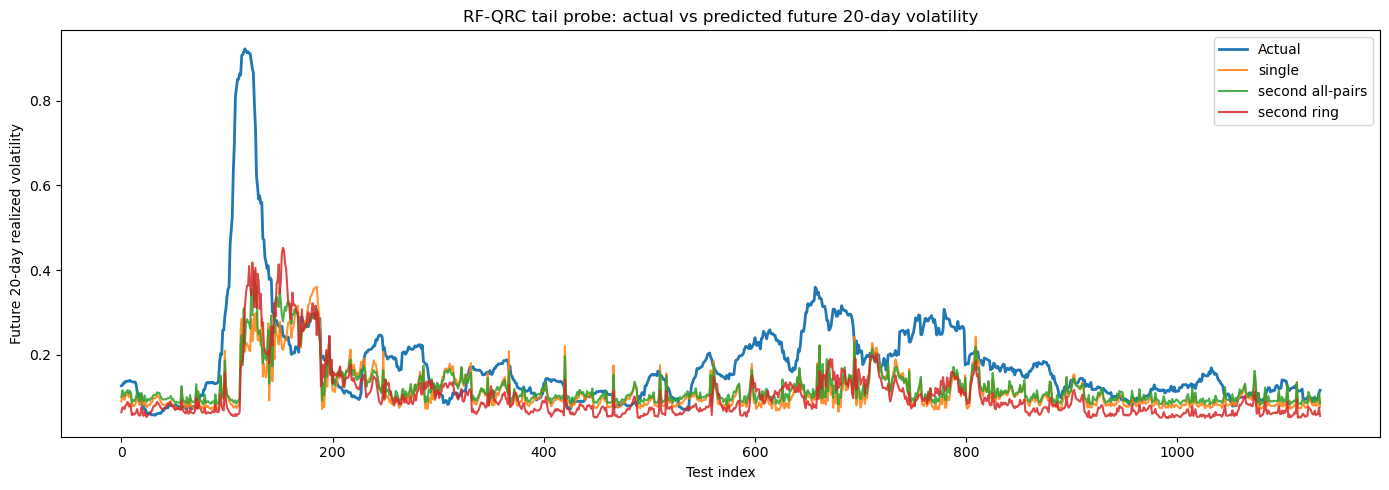

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(test["actual_future_rv_20d"].values, label="Actual", linewidth=2)

for c in pred_cols:
    plt.plot(test[c].values, label=label(c), alpha=0.85)

plt.title("RF-QRC tail probe: actual vs predicted future 20-day volatility")
plt.xlabel("Test index")
plt.ylabel("Future 20-day realized volatility")
plt.legend()
plt.tight_layout()
plt.show()

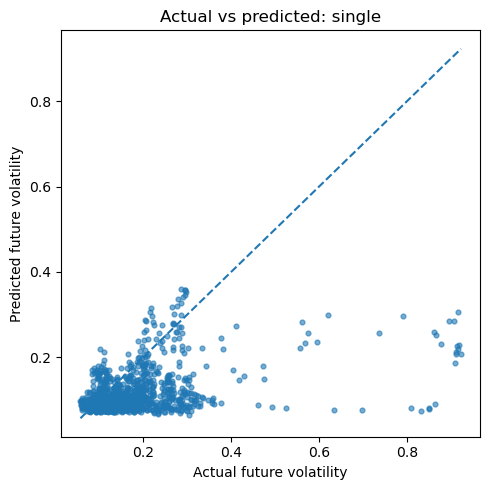

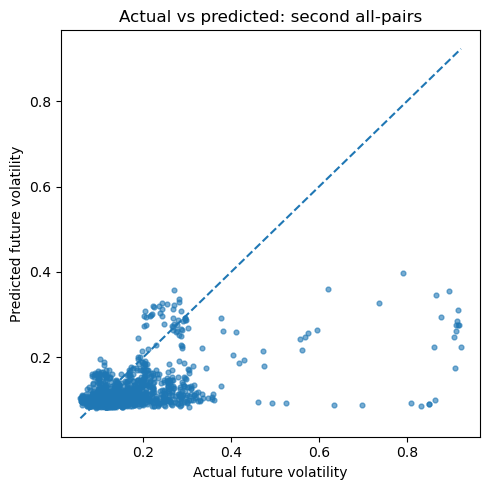

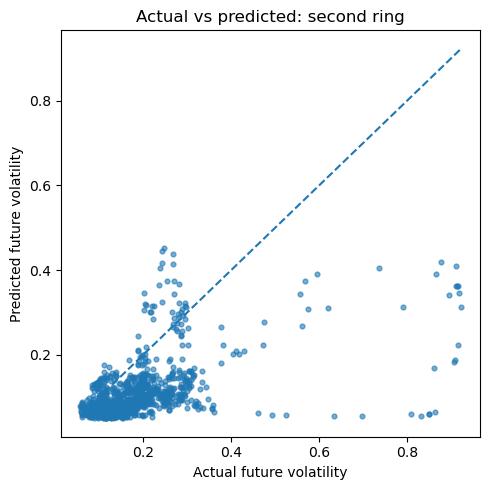

In [6]:
actual = test["actual_future_rv_20d"].values
lo, hi = actual.min(), actual.max()

for c in pred_cols:
    plt.figure(figsize=(5, 5))
    plt.scatter(actual, test[c].values, s=12, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.title(f"Actual vs predicted: {label(c)}")
    plt.xlabel("Actual future volatility")
    plt.ylabel("Predicted future volatility")
    plt.tight_layout()
    plt.show()

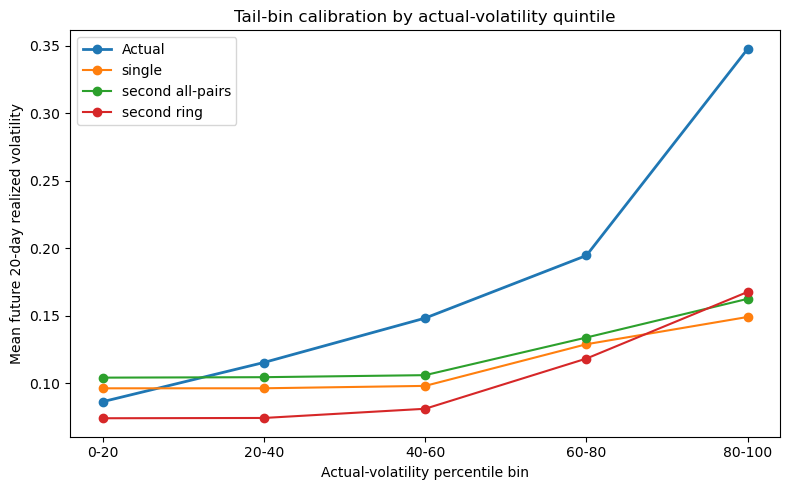

In [7]:
binned = test.copy()
binned["actual_bin"] = pd.qcut(
    binned["actual_future_rv_20d"],
    q=5,
    labels=["0-20", "20-40", "40-60", "60-80", "80-100"]
)

grouped = binned.groupby("actual_bin", observed=True)

plt.figure(figsize=(8, 5))
plt.plot(
    grouped["actual_future_rv_20d"].mean().values,
    marker="o",
    label="Actual",
    linewidth=2,
)

for c in pred_cols:
    plt.plot(grouped[c].mean().values, marker="o", label=label(c))

plt.xticks(range(5), ["0-20", "20-40", "40-60", "60-80", "80-100"])
plt.title("Tail-bin calibration by actual-volatility quintile")
plt.xlabel("Actual-volatility percentile bin")
plt.ylabel("Mean future 20-day realized volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
summary_cols = [
    "run_name", "rmse", "corr", "actual_std", "pred_std",
    "q90_f1", "q95_f1", "top20_pred_actual_ratio", "effective_rank"
]

metrics[metrics["split"] == "test"][summary_cols]

,run_name,rmse,corr,actual_std,pred_std,q90_f1,q95_f1,top20_pred_actual_ratio,effective_rank
2,rf_qrc_single_encode_level_rate,0.128315,0.430179,0.122736,0.050164,0.201258,0.000000,0.428749,7.097886
5,rf_qrc_second_encode_level_rate,0.120873,0.499179,0.122736,0.049225,0.254335,0.166667,0.467545,8.503955
8,rf_qrc_second_encode_ring_level_rate,0.126830,0.556245,0.122736,0.064820,0.320442,0.320000,0.482347,10.926582


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score, mean_squared_error

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

preds = pd.read_csv(
    PROJECT_ROOT / "results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv"
)

preds["date"] = pd.to_datetime(preds["date"])
train = preds[preds["split"] == "train"].copy()
test = preds[preds["split"] == "test"].copy()

actual_col = "actual_future_rv_20d"
model_cols = [
    "rf_qrc_single_encode_level_rate_pred",
    "rf_qrc_second_encode_level_rate_pred",
    "rf_qrc_second_encode_ring_level_rate_pred",
]

labels = {
    "rf_qrc_single_encode_level_rate_pred": "RF-QRC single encode",
    "rf_qrc_second_encode_level_rate_pred": "RF-QRC second encode all-pairs",
    "rf_qrc_second_encode_ring_level_rate_pred": "RF-QRC second encode ring",
}

q80 = train[actual_col].quantile(0.80)
q90 = train[actual_col].quantile(0.90)
q95 = train[actual_col].quantile(0.95)

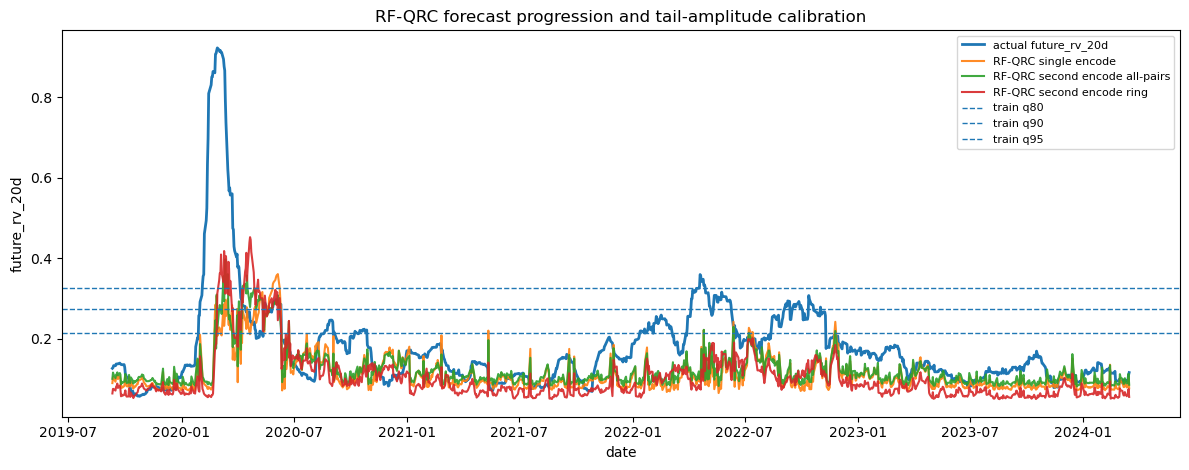

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_forecast_progression_tail_calibration.png


In [10]:
plt.figure(figsize=(12, 4.8))

plt.plot(
    test["date"],
    test[actual_col],
    label="actual future_rv_20d",
    linewidth=2,
)

for c in model_cols:
    plt.plot(
        test["date"],
        test[c],
        label=labels[c],
        alpha=0.9,
    )

plt.axhline(q80, linestyle="--", linewidth=1, label="train q80")
plt.axhline(q90, linestyle="--", linewidth=1, label="train q90")
plt.axhline(q95, linestyle="--", linewidth=1, label="train q95")

plt.title("RF-QRC forecast progression and tail-amplitude calibration")
plt.xlabel("date")
plt.ylabel("future_rv_20d")
plt.legend(fontsize=8)
plt.tight_layout()

out = PROJECT_ROOT / "results/figures/phase3_rf_qrc_forecast_progression_tail_calibration.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [11]:
def binary_f1(y_true, y_pred, threshold):
    return f1_score(y_true >= threshold, y_pred >= threshold, zero_division=0)

rows = []

for c in model_cols:
    y = test[actual_col].values
    p = test[c].values

    rows.append({
        "model": labels[c],
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "q80 watch F1": binary_f1(y, p, q80),
        "q90 warning F1": binary_f1(y, p, q90),
        "q95 crisis-like F1": binary_f1(y, p, q95),
    })

progress = pd.DataFrame(rows)
progress


,model,RMSE,q80 watch F1,q90 warning F1,q95 crisis-like F1
0,RF-QRC single encode,0.128315,0.357143,0.201258,0.000000
1,RF-QRC second encode all-pairs,0.120873,0.389381,0.254335,0.166667
2,RF-QRC second encode ring,0.126830,0.377246,0.320442,0.320000


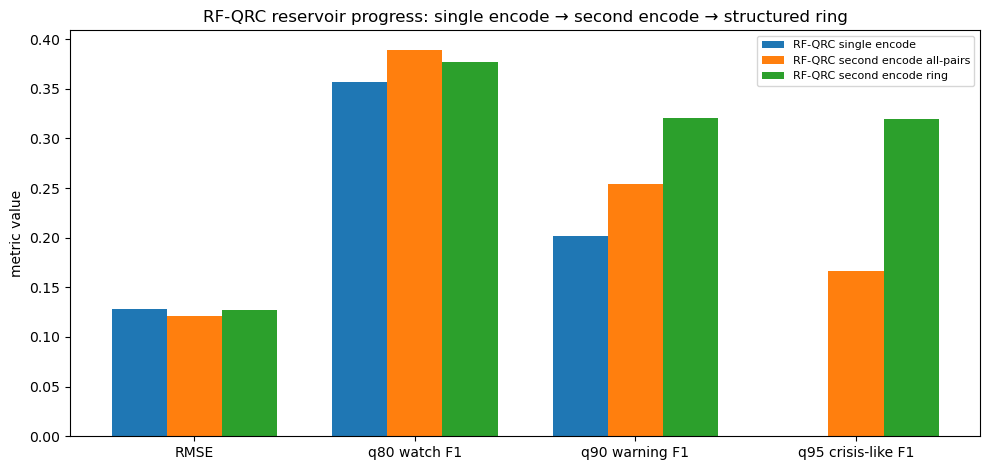

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_reservoir_progress_metrics.png


In [12]:
plot_df = progress.set_index("model")
metrics_to_plot = ["RMSE", "q80 watch F1", "q90 warning F1", "q95 crisis-like F1"]

x = np.arange(len(metrics_to_plot))
width = 0.25

plt.figure(figsize=(10, 4.8))

for i, model in enumerate(plot_df.index):
    plt.bar(
        x + (i - 1) * width,
        plot_df.loc[model, metrics_to_plot].values,
        width,
        label=model,
    )

plt.xticks(x, metrics_to_plot, rotation=0)
plt.ylabel("metric value")
plt.title("RF-QRC reservoir progress: single encode → second encode → structured ring")
plt.legend(fontsize=8)
plt.tight_layout()

out = PROJECT_ROOT / "results/figures/phase3_rf_qrc_reservoir_progress_metrics.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [13]:
actual_col = "actual_future_rv_20d"

train = preds[preds["split"] == "train"]
test = preds[preds["split"] == "test"]

for name, data in [("train", train), ("test", test)]:
    print(name)
    print("n =", len(data))
    print("q80 =", data[actual_col].quantile(0.80))
    print("q90 =", data[actual_col].quantile(0.90))
    print("q95 =", data[actual_col].quantile(0.95))
    print("max =", data[actual_col].max())
    print()

train
n = 5420
q80 = 0.21302130890800716
q90 = 0.27469272225420605
q95 = 0.32627004535247134
max = 0.9242469629024572

test
n = 1136
q80 = 0.2276616730342596
q90 = 0.28312138686898247
q95 = 0.31512574349377015
max = 0.9232012495028388



In [14]:
q80 = train[actual_col].quantile(0.80)
q90 = train[actual_col].quantile(0.90)
q95 = train[actual_col].quantile(0.95)

print(q80, q90, q95)
print("q95 - q90 =", q95 - q90)

0.21302130890800716 0.27469272225420605 0.32627004535247134
q95 - q90 = 0.05157732309826529


In [15]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

files = [
    "results/tables/phase2_feedback_tfim_qrc_reference_predictions.csv",
    "results/tables/phase2_classical_baselines.csv",
    "results/tables/phase2_esn_log_target_confirmation_aggregate.csv",
    "results/tables/phase2_esn_log_target_confirmation_runs.csv",
    "results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv",
]

for f in files:
    df = pd.read_csv(ROOT / f)
    print("\n", f)
    print(df.shape)
    print(df.columns.tolist())
    print(df.head(2))


 results/tables/phase2_feedback_tfim_qrc_reference_predictions.csv
(7658, 5)
['split', 'date', 'actual_future_rv_20d', 'qrc_pred_future_rv_20d', 'run_name']
   split        date  actual_future_rv_20d  qrc_pred_future_rv_20d  \
0  train  1993-06-22              0.097036                0.122106   
1  train  1993-06-23              0.094762                0.098984   

                             run_name  
0  phase2_feedback_tfim_qrc_reference  
1  phase2_feedback_tfim_qrc_reference  

 results/tables/phase2_classical_baselines.csv
(36, 10)
['split', 'model', 'target', 'predictor', 'n', 'rmse', 'qlike', 'mz_alpha', 'mz_beta', 'mz_r2']
  split              model         target       predictor     n      rmse  \
0  test  har_ridge_alpha_1  future_rv_20d  model_forecast  1058  0.100712   
1  test         har_linear  future_rv_20d  model_forecast  1058  0.100712   

      qlike  mz_alpha   mz_beta     mz_r2  
0 -2.079119  0.027659  0.861892  0.353695  
1 -2.079057  0.027668  0.861834  0.353

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, f1_score

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

p2 = pd.read_csv(ROOT / "results/tables/phase2_feedback_tfim_qrc_reference_predictions.csv")
p3 = pd.read_csv(ROOT / "results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv")
esn = pd.read_csv(ROOT / "results/tables/phase2_esn_predictions.csv")

p2["date"] = pd.to_datetime(p2["date"])
p3["date"] = pd.to_datetime(p3["date"])
esn["date"] = pd.to_datetime(esn["date"])

actual_col = "actual_future_rv_20d"

train = p3[p3["split"] == "train"]
q80 = train[actual_col].quantile(0.80)
q90 = train[actual_col].quantile(0.90)
q95 = train[actual_col].quantile(0.95)

p2_test = p2[p2["split"] == "test"][["date", "qrc_pred_future_rv_20d"]]
p3_test = p3[p3["split"] == "test"][
    ["date", actual_col, "rf_qrc_second_encode_ring_level_rate_pred"]
]
esn_test = esn[["date", "esn_pred_future_rv_20d"]]

merged = (
    p3_test
    .merge(p2_test, on="date", how="inner")
    .merge(esn_test, on="date", how="inner")
)

print(merged.shape)
merged.head()

(1019, 5)


,date,actual_future_rv_20d,rf_qrc_second_encode_ring_level_rate_pred,qrc_pred_future_rv_20d,esn_pred_future_rv_20d
0,2020-02-28,0.923201,0.312541,0.221729,0.302564
1,2020-03-02,0.917891,0.345127,0.191613,0.278501
2,2020-03-03,0.913637,0.363067,0.192051,0.336297
3,2020-03-04,0.916564,0.362964,0.194694,0.291668
4,2020-03-05,0.912276,0.409286,0.266205,0.337469


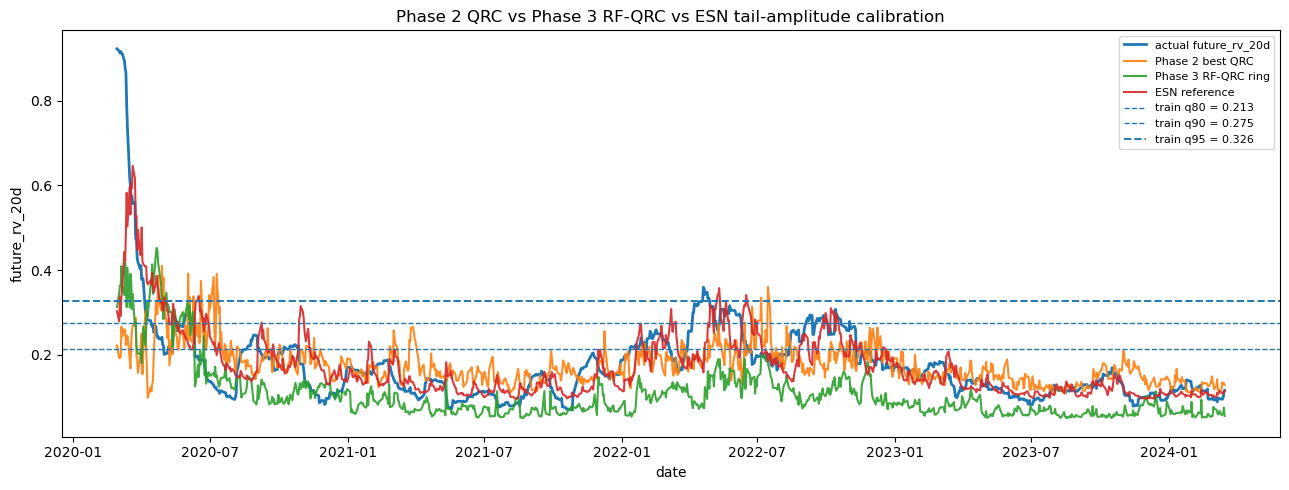

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase2_phase3_qrc_esn_tail_calibration.png


In [17]:
plt.figure(figsize=(13, 5))

plt.plot(
    merged["date"],
    merged[actual_col],
    label="actual future_rv_20d",
    linewidth=2,
)

plt.plot(
    merged["date"],
    merged["qrc_pred_future_rv_20d"],
    label="Phase 2 best QRC",
    alpha=0.9,
)

plt.plot(
    merged["date"],
    merged["rf_qrc_second_encode_ring_level_rate_pred"],
    label="Phase 3 RF-QRC ring",
    alpha=0.9,
)

plt.plot(
    merged["date"],
    merged["esn_pred_future_rv_20d"],
    label="ESN reference",
    alpha=0.9,
)

plt.axhline(q80, linestyle="--", linewidth=1.0, label=f"train q80 = {q80:.3f}")
plt.axhline(q90, linestyle="--", linewidth=1.0, label=f"train q90 = {q90:.3f}")
plt.axhline(q95, linestyle="--", linewidth=1.4, label=f"train q95 = {q95:.3f}")

plt.title("Phase 2 QRC vs Phase 3 RF-QRC vs ESN tail-amplitude calibration")
plt.xlabel("date")
plt.ylabel("future_rv_20d")
plt.legend(fontsize=8)
plt.tight_layout()

out = ROOT / "results/figures/phase2_phase3_qrc_esn_tail_calibration.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [18]:
def score_model(name, y, p, q80, q90, q95):
    return {
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "corr": np.corrcoef(y, p)[0, 1],
        "actual_std": np.std(y),
        "pred_std": np.std(p),
        "q80 watch F1": f1_score(y >= q80, p >= q80, zero_division=0),
        "q90 warning F1": f1_score(y >= q90, p >= q90, zero_division=0),
        "q95 crisis-like F1": f1_score(y >= q95, p >= q95, zero_division=0),
        "top20 pred/actual": np.mean(np.sort(p)[-20:]) / np.mean(np.sort(y)[-20:]),
    }

y = merged[actual_col].values

comparison = pd.DataFrame([
    score_model("Phase 2 best QRC", y, merged["qrc_pred_future_rv_20d"].values, q80, q90, q95),
    score_model("Phase 3 RF-QRC ring", y, merged["rf_qrc_second_encode_ring_level_rate_pred"].values, q80, q90, q95),
    score_model("ESN reference", y, merged["esn_pred_future_rv_20d"].values, q80, q90, q95),
])

comparison

,model,RMSE,corr,actual_std,pred_std,q80 watch F1,q90 warning F1,q95 crisis-like F1,top20 pred/actual
0,Phase 2 best QRC,0.096753,0.388264,0.104783,0.046418,0.379147,0.107383,0.000000,0.480672
1,Phase 3 RF-QRC ring,0.105438,0.666724,0.104783,0.067121,0.397436,0.358025,0.413793,0.542389
2,ESN reference,0.071896,0.728883,0.104783,0.080431,0.672234,0.477064,0.575000,0.705398


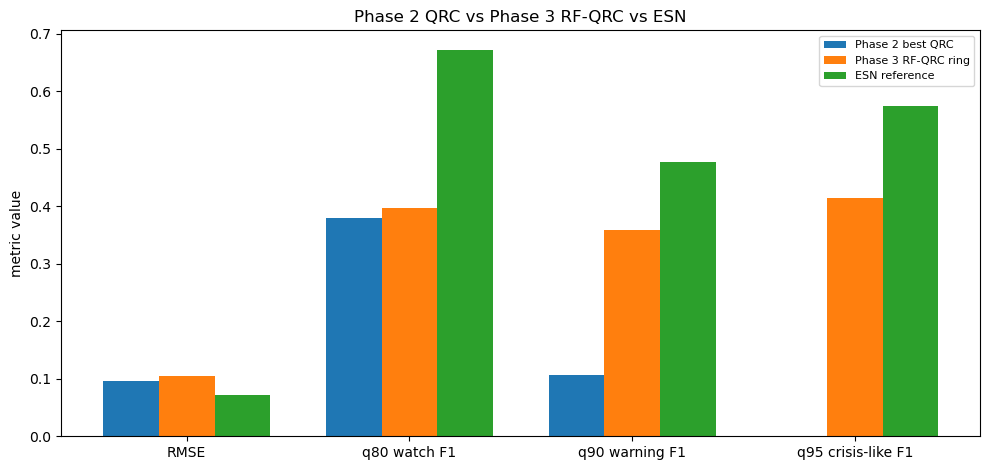

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase2_phase3_qrc_esn_metrics.png


In [19]:
plot_df = comparison.set_index("model")
metrics_to_plot = ["RMSE", "q80 watch F1", "q90 warning F1", "q95 crisis-like F1"]

x = np.arange(len(metrics_to_plot))
width = 0.25

plt.figure(figsize=(10, 4.8))

for i, model in enumerate(plot_df.index):
    plt.bar(
        x + (i - 1) * width,
        plot_df.loc[model, metrics_to_plot].values,
        width,
        label=model,
    )

plt.xticks(x, metrics_to_plot)
plt.ylabel("metric value")
plt.title("Phase 2 QRC vs Phase 3 RF-QRC vs ESN")
plt.legend(fontsize=8)
plt.tight_layout()

out = ROOT / "results/figures/phase2_phase3_qrc_esn_metrics.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()

print(out)

In [20]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

rf_metrics = pd.read_csv(ROOT / "results/tables/phase3_rf_qrc_tail_probe_metrics_level_rate.csv")

print(rf_metrics.columns.tolist())
rf_metrics

['run_name', 'split', 'n', 'rmse', 'qlike', 'corr', 'actual_mean', 'actual_std', 'pred_mean', 'pred_std', 'effective_rank', 'q90_actual_rate', 'q90_pred_rate', 'q90_f1', 'q90_precision', 'q90_recall', 'q95_actual_rate', 'q95_pred_rate', 'q95_f1', 'q95_precision', 'q95_recall', 'top20_actual_mean', 'top20_pred_mean', 'top20_pred_actual_ratio']


,run_name,split,n,rmse,qlike,corr,actual_mean,actual_std,pred_mean,pred_std,...,q90_precision,q90_recall,q95_actual_rate,q95_pred_rate,q95_f1,q95_precision,q95_recall,top20_actual_mean,top20_pred_mean,top20_pred_actual_ratio
0,rf_qrc_single_encode_level_rate,train,5420,0.083574,-0.854997,0.605634,0.163527,0.099319,0.147613,0.038124,...,0.847059,0.132841,0.050000,0.004982,0.087248,0.481481,0.047970,NaN,NaN,NaN
1,rf_qrc_single_encode_level_rate,val,1219,0.067029,-1.061075,0.309305,0.122288,0.060812,0.095670,0.039786,...,0.100000,0.031250,0.000000,0.002461,0.000000,0.000000,0.000000,NaN,NaN,NaN
2,rf_qrc_single_encode_level_rate,test,1136,0.128315,-0.598348,0.430179,0.178373,0.122736,0.113709,0.050164,...,0.551724,0.123077,0.044894,0.006162,0.000000,0.000000,0.000000,0.347153,0.148842,0.428749
3,rf_qrc_second_encode_level_rate,train,5420,0.085405,-0.854530,0.550122,0.163527,0.099319,0.148470,0.040917,...,0.740741,0.110701,0.050000,0.001845,0.042705,0.600000,0.022140,NaN,NaN,NaN
4,rf_qrc_second_encode_level_rate,val,1219,0.059659,-1.105409,0.357466,0.122288,0.060812,0.111841,0.036720,...,0.000000,0.000000,0.000000,0.001641,0.000000,0.000000,0.000000,NaN,NaN,NaN
5,rf_qrc_second_encode_level_rate,test,1136,0.120873,-0.668460,0.499179,0.178373,0.122736,0.122204,0.049225,...,0.511628,0.169231,0.044894,0.007923,0.166667,0.555556,0.098039,0.347153,0.162310,0.467545
6,rf_qrc_second_encode_ring_level_rate,train,5420,0.079051,-0.868468,0.651060,0.163527,0.099319,0.149079,0.045760,...,0.780105,0.274908,0.050000,0.011993,0.220238,0.569231,0.136531,NaN,NaN,NaN
7,rf_qrc_second_encode_ring_level_rate,val,1219,0.070225,-1.006558,0.309714,0.122288,0.060812,0.088395,0.039799,...,0.000000,0.000000,0.000000,0.004102,0.000000,0.000000,0.000000,NaN,NaN,NaN
8,rf_qrc_second_encode_ring_level_rate,test,1136,0.126830,-0.504768,0.556245,0.178373,0.122736,0.103069,0.064820,...,0.568627,0.223077,0.044894,0.021127,0.320000,0.500000,0.235294,0.347153,0.167448,0.482347


In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

def qlike(y, p):
    y = np.maximum(np.asarray(y, dtype=float), 1e-8)
    p = np.maximum(np.asarray(p, dtype=float), 1e-8)
    return float(np.mean(y / p - np.log(y / p) - 1.0))

def mz_metrics(y, p):
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float).reshape(-1, 1)
    model = LinearRegression().fit(p, y)
    y_hat = model.predict(p)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return {
        "mz_alpha": float(model.intercept_),
        "mz_beta": float(model.coef_[0]),
        "mz_r2": float(1.0 - ss_res / ss_tot),
    }

def full_score(name, y, p):
    out = {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, p))),
        "qlike": qlike(y, p),
        "corr": float(np.corrcoef(y, p)[0, 1]),
        "actual_std": float(np.std(y)),
        "pred_std": float(np.std(p)),
    }
    out.update(mz_metrics(y, p))
    return out

y = merged["actual_future_rv_20d"].values

full_comparison = pd.DataFrame([
    full_score("Phase 2 best QRC", y, merged["qrc_pred_future_rv_20d"].values),
    full_score("Phase 3 RF-QRC ring", y, merged["rf_qrc_second_encode_ring_level_rate_pred"].values),
    full_score("ESN reference", y, merged["esn_pred_future_rv_20d"].values),
])

full_comparison

,model,rmse,qlike,corr,actual_std,pred_std,mz_alpha,mz_beta,mz_r2
0,Phase 2 best QRC,0.096753,0.080249,0.388264,0.104783,0.046418,0.023648,0.876463,0.150749
1,Phase 3 RF-QRC ring,0.105438,0.283852,0.666724,0.104783,0.067121,0.066446,1.040823,0.444521
2,ESN reference,0.071896,0.040721,0.728883,0.104783,0.080431,0.011302,0.949564,0.531270


In [22]:
def repo_qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    target_for_qlike = np.maximum(y_true**2, eps)
    pred_for_qlike = np.maximum(y_pred**2, eps)

    return float(np.mean(np.log(pred_for_qlike) + target_for_qlike / pred_for_qlike))

In [23]:
def full_score_repo_metric(name, y, p):
    out = {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, p))),
        "qlike": repo_qlike(y, p),
        "corr": float(np.corrcoef(y, p)[0, 1]),
        "actual_std": float(np.std(y)),
        "pred_std": float(np.std(p)),
    }
    out.update(mz_metrics(y, p))
    return out

full_comparison = pd.DataFrame([
    full_score_repo_metric("Phase 2 best QRC", y, merged["qrc_pred_future_rv_20d"].values),
    full_score_repo_metric("Phase 3 RF-QRC ring", y, merged["rf_qrc_second_encode_ring_level_rate_pred"].values),
    full_score_repo_metric("ESN reference", y, merged["esn_pred_future_rv_20d"].values),
])

full_comparison

,model,rmse,qlike,corr,actual_std,pred_std,mz_alpha,mz_beta,mz_r2
0,Phase 2 best QRC,0.096753,-2.290615,0.388264,0.104783,0.046418,0.023648,0.876463,0.150749
1,Phase 3 RF-QRC ring,0.105438,-1.040723,0.666724,0.104783,0.067121,0.066446,1.040823,0.444521
2,ESN reference,0.071896,-2.504775,0.728883,0.104783,0.080431,0.011302,0.949564,0.531270


In [24]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

actual_col = "actual_future_rv_20d"
pred_col = "rf_qrc_second_encode_ring_level_rate_pred"

val = p3[p3["split"] == "val"].copy()
test = p3[p3["split"] == "test"].copy()

cal = LinearRegression()
cal.fit(
    val[[pred_col]].values,
    val[actual_col].values,
)

test["rf_qrc_ring_mz_calibrated"] = cal.predict(test[[pred_col]].values)
test["rf_qrc_ring_mz_calibrated"] = np.maximum(test["rf_qrc_ring_mz_calibrated"], 1e-8)

print("alpha:", cal.intercept_)
print("beta:", cal.coef_[0])

alpha: 0.0804558023702705
beta: 0.4732388028185078


In [25]:
test["rf_qrc_ring_mz_calibrated"] = (
    0.0804558023702705
    + 0.4732388028185078 * test["rf_qrc_second_encode_ring_level_rate_pred"]
)
test["rf_qrc_ring_mz_calibrated"] = np.maximum(test["rf_qrc_ring_mz_calibrated"], 1e-8)

In [26]:
y = test["actual_future_rv_20d"].values

pd.DataFrame([
    score_model(
        "RF-QRC ring raw",
        y,
        test["rf_qrc_second_encode_ring_level_rate_pred"].values,
        q80, q90, q95,
    ),
    score_model(
        "RF-QRC ring MZ calibrated",
        y,
        test["rf_qrc_ring_mz_calibrated"].values,
        q80, q90, q95,
    ),
])

,model,RMSE,corr,actual_std,pred_std,q80 watch F1,q90 warning F1,q95 crisis-like F1,top20 pred/actual
0,RF-QRC ring raw,0.126830,0.556245,0.122736,0.064820,0.377246,0.320442,0.32,0.450741
1,RF-QRC ring MZ calibrated,0.119295,0.556245,0.122736,0.030675,0.286624,0.014706,0.00,0.305431


In [27]:
pd.DataFrame([
    full_score_repo_metric(
        "RF-QRC ring raw",
        y,
        test["rf_qrc_second_encode_ring_level_rate_pred"].values,
    ),
    full_score_repo_metric(
        "RF-QRC ring MZ calibrated",
        y,
        test["rf_qrc_ring_mz_calibrated"].values,
    ),
])

,model,rmse,qlike,corr,actual_std,pred_std,mz_alpha,mz_beta,mz_r2
0,RF-QRC ring raw,0.126830,0.234887,0.556245,0.122736,0.064820,0.069817,1.053238,0.309408
1,RF-QRC ring MZ calibrated,0.119295,-1.753095,0.556245,0.122736,0.030675,-0.109245,2.225595,0.309408


In [28]:
p2_val = p2[p2["split"] == "val"][["date", "qrc_pred_future_rv_20d"]].copy()
p3_val = p3[p3["split"] == "val"][
    ["date", "actual_future_rv_20d", "rf_qrc_second_encode_ring_level_rate_pred"]
].copy()

val_merge = p3_val.merge(p2_val, on="date", how="inner")

alphas = np.linspace(0, 1, 101)
rows = []

for a in alphas:
    pred = (
        (1 - a) * val_merge["qrc_pred_future_rv_20d"].values
        + a * val_merge["rf_qrc_second_encode_ring_level_rate_pred"].values
    )
    yv = val_merge["actual_future_rv_20d"].values

    rows.append({
        "alpha_rf_qrc": a,
        "rmse": np.sqrt(mean_squared_error(yv, pred)),
        "qlike_repo": repo_qlike(yv, pred),
        "corr": np.corrcoef(yv, pred)[0, 1],
        "pred_std": np.std(pred),
        "q90_f1": f1_score(yv >= q90, pred >= q90, zero_division=0),
        "q95_f1": f1_score(yv >= q95, pred >= q95, zero_division=0),
    })

blend_val = pd.DataFrame(rows)

blend_val.sort_values("qlike_repo").head(10)

,alpha_rf_qrc,rmse,qlike_repo,corr,pred_std,q90_f1,q95_f1
23,0.23,0.061773,-3.004071,0.323901,0.032335,0.0,0.0
22,0.22,0.061983,-3.004056,0.322325,0.032404,0.0,0.0
24,0.24,0.061571,-3.003981,0.325435,0.032271,0.0,0.0
21,0.21,0.062201,-3.003940,0.320708,0.032478,0.0,0.0
25,0.25,0.061378,-3.003785,0.326926,0.032212,0.0,0.0
20,0.20,0.062427,-3.003726,0.319052,0.032556,0.0,0.0
26,0.26,0.061192,-3.003478,0.328372,0.032157,0.0,0.0
19,0.19,0.062660,-3.003416,0.317357,0.032639,0.0,0.0
27,0.27,0.061015,-3.003059,0.329773,0.032108,0.0,0.0
18,0.18,0.062902,-3.003012,0.315626,0.032727,0.0,0.0


In [29]:
blend_val.assign(
    objective = (
        blend_val["q90_f1"]
        + blend_val["q95_f1"]
        + 0.5 * blend_val["corr"]
        - 2.0 * np.maximum(0, blend_val["rmse"] - 0.0968)
    )
).sort_values("objective", ascending=False).head(10)

,alpha_rf_qrc,rmse,qlike_repo,corr,pred_std,q90_f1,q95_f1,objective
53,0.53,0.059503,-2.938928,0.347996,0.032575,0.0,0.0,0.173998
54,0.54,0.059567,-2.933731,0.347978,0.032659,0.0,0.0,0.173989
52,0.52,0.059448,-2.943866,0.347963,0.032495,0.0,0.0,0.173982
55,0.55,0.059640,-2.928265,0.347910,0.032748,0.0,0.0,0.173955
51,0.51,0.059402,-2.948552,0.347879,0.032420,0.0,0.0,0.173940
56,0.56,0.059722,-2.922521,0.347794,0.032842,0.0,0.0,0.173897
50,0.50,0.059365,-2.952995,0.347743,0.032350,0.0,0.0,0.173872
57,0.57,0.059813,-2.916489,0.347630,0.032940,0.0,0.0,0.173815
49,0.49,0.059338,-2.957203,0.347555,0.032285,0.0,0.0,0.173777
58,0.58,0.059913,-2.910159,0.347418,0.033043,0.0,0.0,0.173709


In [30]:
for split_name, df in [
    ("phase2 train", p2[p2["split"] == "train"]),
    ("phase2 val", p2[p2["split"] == "val"]),
    ("phase2 test", p2[p2["split"] == "test"]),
    ("phase3 train", p3[p3["split"] == "train"]),
    ("phase3 val", p3[p3["split"] == "val"]),
    ("phase3 test", p3[p3["split"] == "test"]),
]:
    print(split_name)
    print("n:", len(df))
    print("max actual:", df["actual_future_rv_20d"].max())
    print("actual >= q90:", (df["actual_future_rv_20d"] >= q90).sum())
    print("actual >= q95:", (df["actual_future_rv_20d"] >= q95).sum())
    print()

phase2 train
n: 5420
max actual: 0.9242469629024572
actual >= q90: 542
actual >= q95: 271

phase2 val
n: 1219
max actual: 0.3189041106975884
actual >= q90: 32
actual >= q95: 0

phase2 test
n: 1019
max actual: 0.9232012495028388
actual >= q90: 111
actual >= q95: 34

phase3 train
n: 5420
max actual: 0.9242469629024572
actual >= q90: 542
actual >= q95: 271

phase3 val
n: 1219
max actual: 0.3189041106975884
actual >= q90: 32
actual >= q95: 0

phase3 test
n: 1136
max actual: 0.9232012495028388
actual >= q90: 130
actual >= q95: 51



In [37]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_squared_error, f1_score

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

final_qrc = pd.read_csv(
    ROOT / "results/tables/phase2_qrc_final_encoding_readout_predictions.csv"
)
final_metrics = pd.read_csv(
    ROOT / "results/tables/phase2_qrc_final_encoding_readout_prediction_export_metrics.csv"
)

print("Final QRC metrics:")
display(final_metrics)

print("\nFinal QRC predictions:")
print(final_qrc.shape)
print(final_qrc.columns.tolist())
display(final_qrc.head())

print("\nPrediction range:")
print(final_qrc["qrc_pred_future_rv_20d"].describe())

Final QRC metrics:


,run_name,split,rmse,qlike,mz_r2,corr,pred_std
0,linear_clip_top240_alpha1000,train,0.073861,-2.607141,0.469223,0.684999,0.057300
1,linear_clip_top240_alpha1000,val,0.060027,-3.020763,0.138672,0.372387,0.039186
2,linear_clip_top240_alpha1000,test,0.095082,-2.229724,0.188898,0.434624,0.054796



Final QRC predictions:
(1019, 4)
['date', 'actual_future_rv_20d', 'qrc_pred_future_rv_20d', 'run_name']


,date,actual_future_rv_20d,qrc_pred_future_rv_20d,run_name
0,2020-02-28,0.923201,0.168038,linear_clip_top240_alpha1000
1,2020-03-02,0.917891,0.179526,linear_clip_top240_alpha1000
2,2020-03-03,0.913637,0.200856,linear_clip_top240_alpha1000
3,2020-03-04,0.916564,0.158109,linear_clip_top240_alpha1000
4,2020-03-05,0.912276,0.170180,linear_clip_top240_alpha1000



Prediction range:
count    1019.000000
mean        0.170101
std         0.054823
min         0.086847
25%         0.121729
50%         0.160161
75%         0.215322
max         0.364332
Name: qrc_pred_future_rv_20d, dtype: float64


In [32]:
# q80/q90/q95 from the same train distribution you already used
print("thresholds:")
print("q80:", q80)
print("q90:", q90)
print("q95:", q95)

p = final_qrc["qrc_pred_future_rv_20d"].values
y = final_qrc["actual_future_rv_20d"].values

print("\nFinal restored QRC:")
print("max actual:", y.max())
print("max pred:", p.max())
print("actual >= q90:", (y >= q90).sum())
print("actual >= q95:", (y >= q95).sum())
print("pred >= q90:", (p >= q90).sum())
print("pred >= q95:", (p >= q95).sum())
print("q90 F1:", f1_score(y >= q90, p >= q90, zero_division=0))
print("q95 F1:", f1_score(y >= q95, p >= q95, zero_division=0))
print("top20 pred/actual:", np.mean(np.sort(p)[-20:]) / np.mean(np.sort(y)[-20:]))

thresholds:
q80: 0.21302130890800716
q90: 0.27469272225420605
q95: 0.32627004535247134

Final restored QRC:
max actual: 0.9232012495028388
max pred: 0.3643324098325403
actual >= q90: 111
actual >= q95: 34
pred >= q90: 39
pred >= q95: 4
q90 F1: 0.12
q95 F1: 0.0
top20 pred/actual: 0.4303127715771316


In [36]:
final_qrc = pd.read_csv(ROOT / "results/tables/phase2_qrc_final_encoding_readout_predictions.csv")
final_qrc["date"] = pd.to_datetime(final_qrc["date"])

p3 = pd.read_csv(ROOT / "results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv")
p3["date"] = pd.to_datetime(p3["date"])

esn = pd.read_csv(ROOT / "results/tables/phase2_esn_predictions.csv")
esn["date"] = pd.to_datetime(esn["date"])

merged_final = (
    p3[p3["split"] == "test"][
        ["date", "actual_future_rv_20d", "rf_qrc_second_encode_ring_level_rate_pred"]
    ]
    .merge(
        final_qrc[["date", "qrc_pred_future_rv_20d"]],
        on="date",
        how="inner",
    )
    .merge(
        esn[["date", "esn_pred_future_rv_20d"]],
        on="date",
        how="inner",
    )
)

y = merged_final["actual_future_rv_20d"].values

comparison_final = pd.DataFrame([
    score_model("Phase 2 final QRC", y, merged_final["qrc_pred_future_rv_20d"].values, q80, q90, q95),
    score_model("Phase 3 RF-QRC ring", y, merged_final["rf_qrc_second_encode_ring_level_rate_pred"].values, q80, q90, q95),
    score_model("ESN reference", y, merged_final["esn_pred_future_rv_20d"].values, q80, q90, q95),
])

comparison_final

,model,RMSE,corr,actual_std,pred_std,q80 watch F1,q90 warning F1,q95 crisis-like F1,top20 pred/actual
0,Phase 2 final QRC,0.095082,0.434624,0.104783,0.054796,0.559687,0.120000,0.000000,0.430313
1,Phase 3 RF-QRC ring,0.105438,0.666724,0.104783,0.067121,0.397436,0.358025,0.413793,0.542389
2,ESN reference,0.071896,0.728883,0.104783,0.080431,0.672234,0.477064,0.575000,0.705398


In [34]:
full_comparison_final = pd.DataFrame([
    full_score_repo_metric("Phase 2 final QRC", y, merged_final["qrc_pred_future_rv_20d"].values),
    full_score_repo_metric("Phase 3 RF-QRC ring", y, merged_final["rf_qrc_second_encode_ring_level_rate_pred"].values),
    full_score_repo_metric("ESN reference", y, merged_final["esn_pred_future_rv_20d"].values),
])

full_comparison_final

,model,rmse,qlike,corr,actual_std,pred_std,mz_alpha,mz_beta,mz_r2
0,Phase 2 final QRC,0.095082,-2.229724,0.434624,0.104783,0.054796,0.035765,0.831094,0.188898
1,Phase 3 RF-QRC ring,0.105438,-1.040723,0.666724,0.104783,0.067121,0.066446,1.040823,0.444521
2,ESN reference,0.071896,-2.504775,0.728883,0.104783,0.080431,0.011302,0.949564,0.531270


In [35]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

out_table_dir = ROOT / "results/tables"

target = "future_rv_20d"

# Load original data and rebuild the same old Phase 2 timeline/stress flags
from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.splits import chronological_tabular_split

def make_stress_features(frame):
    out = frame.copy().reset_index(drop=True)
    out["date"] = pd.to_datetime(out["date"])
    out["spy_selloff_stress"] = -out["spy_log_return"]
    out["spy_oc_selloff_stress"] = -out["spy_log_oc_return"]
    out["drawdown_stress"] = (
        -out["spy_drawdown_20d"]
        if out["spy_drawdown_20d"].median() < 0
        else out["spy_drawdown_20d"]
    )
    out["volume_stress"] = out["spy_log_volume_change"].abs()
    out["vix_level_stress"] = out["vix_close"]
    out["vix_change_stress"] = out["vix_log_change"].clip(lower=0.0)
    out["vix_range_stress"] = out["vix_log_hl_range"]
    out["realized_vol_stress"] = out["rv_20d"]
    return out

df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)
splits = {k: make_stress_features(v) for k, v in splits.items()}

train = splits["train"]
test = splits["test"].copy()

thresholds = {
    "high_vol_q80": float(train[target].quantile(0.80)),
    "extreme_vol_q90": float(train[target].quantile(0.90)),
    "crisis_candidate_q95": float(train[target].quantile(0.95)),
}

for split in [train, test]:
    split["future_high_vol_event_q80"] = split[target] > thresholds["high_vol_q80"]
    split["future_extreme_vol_event_q90"] = split[target] > thresholds["extreme_vol_q90"]
    split["future_crisis_candidate_q95"] = split[target] > thresholds["crisis_candidate_q95"]

def q(col, quantile, split=train):
    return float(split[col].quantile(quantile))

timeline = test.copy().reset_index(drop=True)

timeline["direction_tag"] = "neutral"
timeline.loc[timeline["spy_log_return"] >= q("spy_log_return", 0.70), "direction_tag"] = "rally"
timeline.loc[timeline["spy_log_return"] <= q("spy_log_return", 0.30), "direction_tag"] = "selloff"

flag_specs = {
    "flag_realized_vol": ("rv_20d", 0.80),
    "flag_vix_level": ("vix_close", 0.80),
    "flag_vix_range": ("vix_log_hl_range", 0.80),
    "flag_drawdown": ("drawdown_stress", 0.80),
    "flag_selloff": ("spy_selloff_stress", 0.80),
    "flag_volume": ("volume_stress", 0.80),
    "flag_vol_acceleration": ("rv_slope_5_20", 0.80),
}

for flag, (col, quantile) in flag_specs.items():
    timeline[flag] = timeline[col] > q(col, quantile)

FileNotFoundError: Processed Phase 2 dataset not found: data/processed/phase2_spy_vix_volatility.csv. Run `python scripts/prepare_phase2_spy_vix_dataset.py` first.